In [1]:
import pandas as pd
import csv

In [2]:
def parse_params(params_str):
    params = {}
    for item in params_str.split():
        if '=' in item:
            key, value = item.split('=', 1)
            params[key] = value
    return params

# aggregates results over all parameters except those in params_to_compare
def results_csv_to_df(csv_file, params_to_compare):
    results = []

    with open(csv_file, newline='') as f:
        reader = csv.DictReader(f, fieldnames=[
            'accuracy', 'correctly_filled_cells', 'nfe', 'time', 'speed', 'not_fully_unmasked',
            'checkpoint', 'strategy', 'params'
        ])
        reader.__next__()  # Skip header row
        for row in reader:
            params = parse_params(row['params'])
            relevant_params = {k: v for k, v in params.items() if k in params_to_compare}
            row_dict = {
                'accuracy': float(row['accuracy']),
                'correctly_filled_cells': float(row['correctly_filled_cells']),
                'checkpoint': row['checkpoint'],
                'strategy': row['strategy'],
                'nfe': float(row['nfe']),
                'time': float(row['time']),
                'speed': float(row['speed']),
            }
            row_dict.update(relevant_params)
            results.append(row_dict)
    
    results_df = pd.DataFrame(results)
    aggregated_df = results_df.groupby(params_to_compare + ['checkpoint', 'strategy']).agg(
        accuracy_mean=pd.NamedAgg(column='accuracy', aggfunc='mean'),
        accuracy_std=pd.NamedAgg(column='accuracy', aggfunc='std'),
        correctly_filled_cells_mean=pd.NamedAgg(column='correctly_filled_cells', aggfunc='mean'),
        correctly_filled_cells_std=pd.NamedAgg(column='correctly_filled_cells', aggfunc='std'),
        nfe=pd.NamedAgg(column='nfe', aggfunc='mean'),
        time=pd.NamedAgg(column='time', aggfunc='mean'),
        speed=pd.NamedAgg(column='speed', aggfunc='mean'),
    ).reset_index()

    return aggregated_df

In [3]:
params_to_compare=['pruning_num_beams', 'branching_factor', 'score_time', 'score_method']
df = results_csv_to_df('results_compare_beam_search_parameters.csv', params_to_compare)
df

,pruning_num_beams,branching_factor,score_time,score_method,checkpoint,strategy,accuracy_mean,accuracy_std,correctly_filled_cells_mean,correctly_filled_cells_std,nfe,time,speed
0,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,0.7156,NaN,0.8745,NaN,94.14,824.0,0.78
1,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,0.7203,NaN,0.8740,NaN,101.97,917.0,0.70
2,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,0.7156,NaN,0.8745,NaN,94.18,811.0,0.79
3,1,2,inferred,avg,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,0.7203,NaN,0.8750,NaN,102.14,949.0,0.67
4,1,2,inferred,avg,checkpoints/mdlm/300_epochs,mdlm_adaptive_score_select_update,0.6781,NaN,0.8663,NaN,85.90,671.0,0.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,0.7953,NaN,0.9065,NaN,332.01,2840.0,0.23
116,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,0.7891,NaN,0.9000,NaN,409.90,3546.0,0.18
117,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,0.7953,NaN,0.9060,NaN,334.11,2910.0,0.22
118,4,4,t_zero,min,checkpoints/gidd_0_2/300_epochs,gidd_prob_to_recover_data,0.7812,NaN,0.9018,NaN,342.67,3192.0,0.20


In [6]:
# compare score_method
score_methods = df.groupby(['checkpoint', 'strategy'] + [param for param in params_to_compare if param != 'score_method'] + ['score_method'])['accuracy_mean'].mean().unstack()
# score_methods = df.groupby(['checkpoint', 'strategy'] + ['score_method'])['accuracy_mean'].mean().unstack()
score_methods

score_method                                                                                                                      avg  \
checkpoint                      strategy                                        pruning_num_beams branching_factor score_time           
checkpoints/gidd_0_2/300_epochs gidd_change_based_on_model_confidence_to_change 1                 2                inferred    0.7156   
                                                                                                                   t_zero      0.7078   
                                                                                2                 2                inferred    0.7312   
                                                                                                                   t_zero      0.7297   
                                                                                                  4                inferred    0.7766   
                                                                                                                   t_zero      0.7531   
                                                                                4                 4                inferred    0.8016   
                                                                                                                   t_zero      0.7969   
                                gidd_change_low_confidence_positions            1                 2                inferred    0.7203   
                                                                                                                   t_zero      0.7063   
                                                                                2                 2                inferred    0.7375   
                                                                                                                   t_zero      0.7359   
                                                                                                  4                inferred    0.7828   
                                                                                                                   t_zero      0.7688   
                                                                                4                 4                inferred    0.8094   
                                                                                                                   t_zero      0.8047   
                                gidd_keep_where_confident                       1                 2                inferred    0.7156   
                                                                                                                   t_zero      0.7078   
                                                                                2                 2                inferred    0.7312   
                                                                                                                   t_zero      0.7297   
                                                                                                  4                inferred    0.7766   
                                                                                                                   t_zero      0.7531   
                                                                                4                 4                inferred    0.8016   
                                                                                                                   t_zero      0.7969   
                                gidd_prob_to_recover_data                       1                 2                inferred    0.7203   
                                                                                                                   t_zero      0.7156   
                                                                                2                 2                inferred    0.7328   
                           

In [7]:
# compare score_time
score_time = df.groupby(['checkpoint', 'strategy'] + [param for param in params_to_compare if param != 'score_time'] + ['score_time'])['accuracy_mean'].mean().unstack()
# score_time = df.groupby(['checkpoint', 'strategy'] + ['score_time'])['accuracy_mean'].mean().unstack()
score_time

score_time                                                                                                                                              inferred  \
checkpoint                      strategy                                        pruning_num_beams branching_factor score_method                                    
checkpoints/gidd_0_2/300_epochs gidd_change_based_on_model_confidence_to_change 1                 2                avg                                    0.7156   
                                                                                                                   avg_all_using_confidence_for_masked    0.7156   
                                                                                                                   min                                    0.7188   
                                                                                2                 2                avg                                    0.7312   
                                                                                                                   avg_all_using_confidence_for_masked    0.7297   
                                                                                                                   min                                    0.7312   
                                                                                                  4                avg                                    0.7766   
                                                                                                                   avg_all_using_confidence_for_masked    0.7641   
                                                                                                                   min                                    0.7750   
                                                                                4                 4                avg                                    0.8016   
                                                                                                                   avg_all_using_confidence_for_masked    0.7859   
                                                                                                                   min                                    0.7969   
                                gidd_change_low_confidence_positions            1                 2                avg                                    0.7203   
                                                                                                                   avg_all_using_confidence_for_masked    0.7156   
                                                                                                                   min                                    0.7188   
                                                                                2                 2                avg                                    0.7375   
                                                                                                                   avg_all_using_confidence_for_masked    0.7328   
                                                                                                                   min                                    0.7328   
                                                                                                  4                avg                                    0.7828   
                                                                                                                   avg_all_using_confidence_for_masked    0.7719   
                                                                                                                   min                                    0.7844   
                                                                                4                 4                avg                                    0.8094   
                                                                

In [8]:
# Get best score_method and score_time per pruning_num_beams and branching_factor
best_method_and_time = df.loc[df.groupby(['checkpoint', 'strategy', 'pruning_num_beams', 'branching_factor'])['accuracy_mean'].idxmax()]#.reset_index(drop=True)
best_method_and_time[['checkpoint', 'strategy', 'pruning_num_beams', 'branching_factor', 'score_method', 'score_time', 'accuracy_mean', 'nfe', 'speed']]

,checkpoint,strategy,pruning_num_beams,branching_factor,score_method,score_time,accuracy_mean,nfe,speed
10,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,1,2,min,inferred,0.7188,94.28,0.79
30,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,2,2,avg,inferred,0.7312,111.53,0.64
60,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,2,4,avg,inferred,0.7766,237.30,0.32
90,checkpoints/gidd_0_2/300_epochs,gidd_change_based_on_model_confidence_to_change,4,4,avg,inferred,0.8016,324.03,0.23
1,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,1,2,avg,inferred,0.7203,101.97,0.70
31,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,2,2,avg,inferred,0.7375,129.69,0.55
71,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,2,4,min,inferred,0.7844,274.44,0.26
91,checkpoints/gidd_0_2/300_epochs,gidd_change_low_confidence_positions,4,4,avg,inferred,0.8094,391.82,0.19
12,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,1,2,min,inferred,0.7188,94.28,0.78
32,checkpoints/gidd_0_2/300_epochs,gidd_keep_where_confident,2,2,avg,inferred,0.7312,111.66,0.66


/tmp/ipykernel_2387576/4026978002.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


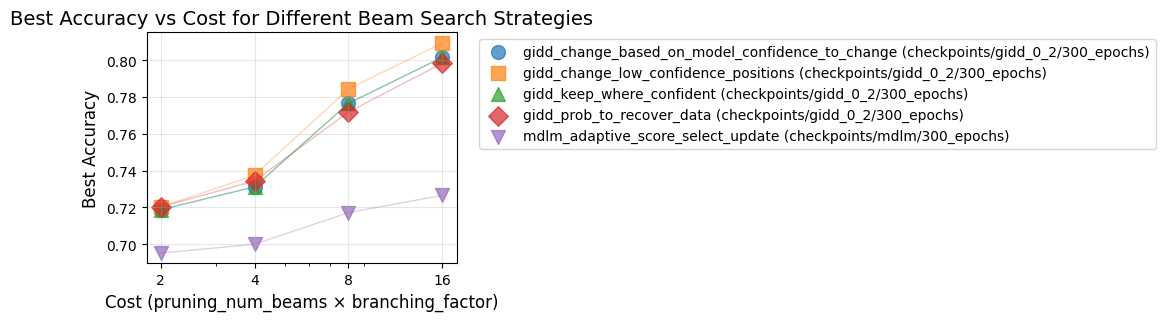

In [9]:
# Plot the best accuracy for each strategy over the cost (=pruning_num_beams * branching_factor)
import matplotlib.pyplot as plt

# Calculate cost and prepare data for plotting
best_method_and_time['cost'] = best_method_and_time['pruning_num_beams'].astype(int) * best_method_and_time['branching_factor'].astype(int)

# Create the plot
plt.figure(figsize=(4, 3))

# Get unique strategies and checkpoints for plotting
strategies = best_method_and_time['strategy'].unique()
checkpoints = best_method_and_time['checkpoint'].unique()

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))

plot_idx = 0
for strategy in strategies:
    for checkpoint in checkpoints:
        subset = best_method_and_time[
            (best_method_and_time['strategy'] == strategy) & 
            (best_method_and_time['checkpoint'] == checkpoint)
        ]
        
        if not subset.empty:
            plt.scatter(subset['cost'], subset['accuracy_mean'], 
                       label=f'{strategy} ({checkpoint})',
                       marker=markers[plot_idx % len(markers)],
                       color=colors[plot_idx],
                       s=100, alpha=0.7)
            
            # Connect points with lines for the same strategy-checkpoint combination
            subset_sorted = subset.sort_values('cost')
            plt.plot(subset_sorted['cost'], subset_sorted['accuracy_mean'],
                    color=colors[plot_idx], alpha=0.3, linewidth=1)
            
            plot_idx += 1

plt.xlabel('Cost (pruning_num_beams × branching_factor)', fontsize=12)
plt.ylabel('Best Accuracy', fontsize=12)
plt.title('Best Accuracy vs Cost for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Make cost axis logarithmic and set specific ticks only
plt.xscale('log')
plt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])
# Disable minor ticks to prevent automatic labels
plt.gca().xaxis.set_minor_formatter(plt.NullFormatter())
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2387576/2408669718.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


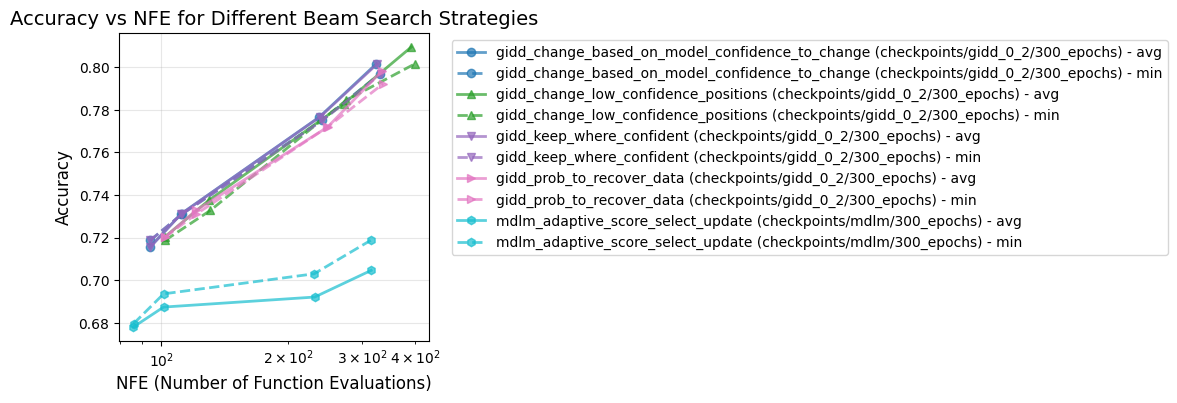

In [29]:
# Plot accuracy vs NFE for each strategy with two lines per strategy (avg and min score_method)
import matplotlib.pyplot as plt

# Filter data for score_time='inferred' and score_method in ['avg', 'min']
filtered_data = df[
    (df['score_time'] == 'inferred') & 
    (df['score_method'].isin(['avg', 'min']))
]

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies and checkpoints for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()
score_methods = ['avg', 'min']

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints) * len(score_methods)))

plot_idx = 0
for strategy in strategies:
    for checkpoint in checkpoints:
        strategy_color = colors[plot_idx]
        
        for i, score_method in enumerate(score_methods):
            subset = filtered_data[
                (filtered_data['strategy'] == strategy) & 
                (filtered_data['checkpoint'] == checkpoint) &
                (filtered_data['score_method'] == score_method)
            ]
            
            if not subset.empty:
                # Sort by NFE for proper line connection
                subset_sorted = subset.sort_values('nfe')
                
                # Use solid line for avg, dashed for min
                linestyle = '-' if score_method == 'avg' else '--'
                label = f'{strategy} ({checkpoint}) - {score_method}'
                
                plt.plot(subset_sorted['nfe'], subset_sorted['accuracy_mean'], 
                        label=label,
                        marker=markers[plot_idx % len(markers)],
                        color=strategy_color,
                        linestyle=linestyle,
                        markersize=6, alpha=0.7, linewidth=2)
        
        plot_idx += 1

plt.xlabel('NFE (Number of Function Evaluations)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs NFE for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2387576/3597191806.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


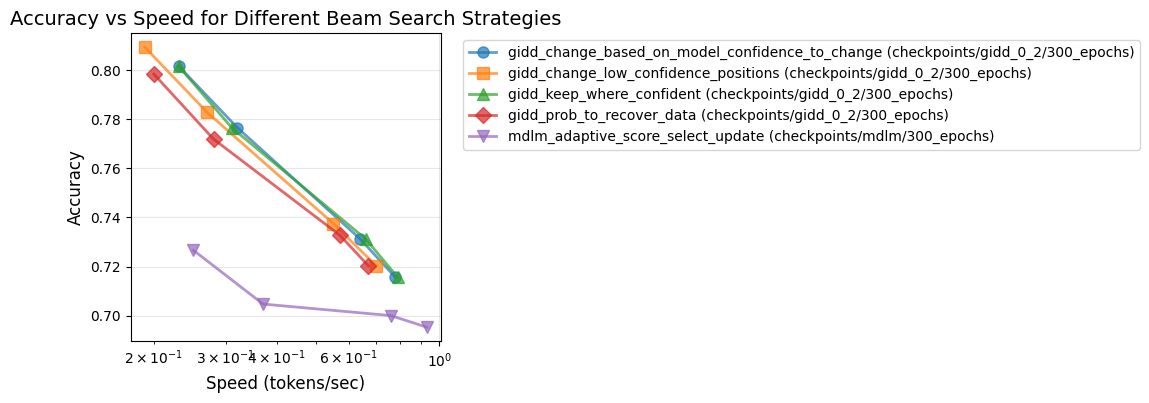

In [27]:
# Plot accuracy vs speed for each strategy with specific filtering
import matplotlib.pyplot as plt

# Filter data based on the specified conditions (same as previous plot)
filtered_data = df[
    # For most strategies: score_method='avg' and score_time='inferred'
    ((df['strategy'] != 'mdlm_adaptive_score_select_update') & 
     (df['score_method'] == 'avg') & 
     (df['score_time'] == 'inferred')) |
    # For mdlm_adaptive_score_select_update: score_method='avg_all_using_confidence_for_masked' and score_time='t_zero'
    ((df['strategy'] == 'mdlm_adaptive_score_select_update') & 
     (df['score_method'] == 'avg_all_using_confidence_for_masked') & 
     (df['score_time'] == 't_zero'))
]

# Create the plot
plt.figure(figsize=(4, 4))

# Get unique strategies for plotting
strategies = filtered_data['strategy'].unique()
checkpoints = filtered_data['checkpoint'].unique()

# Use different markers and colors for each strategy-checkpoint combination
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
colors = plt.cm.tab10(range(len(strategies) * len(checkpoints)))

plot_idx = 0
for strategy in strategies:
    for checkpoint in checkpoints:
        subset = filtered_data[
            (filtered_data['strategy'] == strategy) & 
            (filtered_data['checkpoint'] == checkpoint)
        ]
        
        if not subset.empty:
            # Sort by speed for proper line connection
            subset_sorted = subset.sort_values('speed')
            
            plt.plot(subset_sorted['speed'], subset_sorted['accuracy_mean'], 
                    label=f'{strategy} ({checkpoint})',
                    marker=markers[plot_idx % len(markers)],
                    color=colors[plot_idx],
                    markersize=8, alpha=0.7, linewidth=2)
            
            plot_idx += 1

plt.xlabel('Speed (tokens/sec)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Speed for Different Beam Search Strategies', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xscale('log')
plt.tight_layout()
plt.show()
